In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
df.shape

(2200, 8)

In [5]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

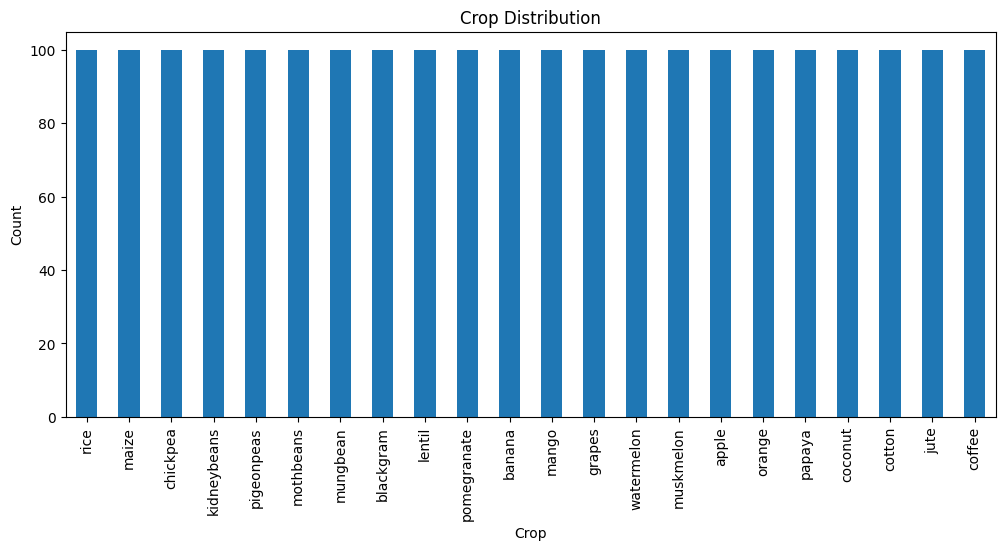

In [9]:
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar',figsize=(12,5))

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

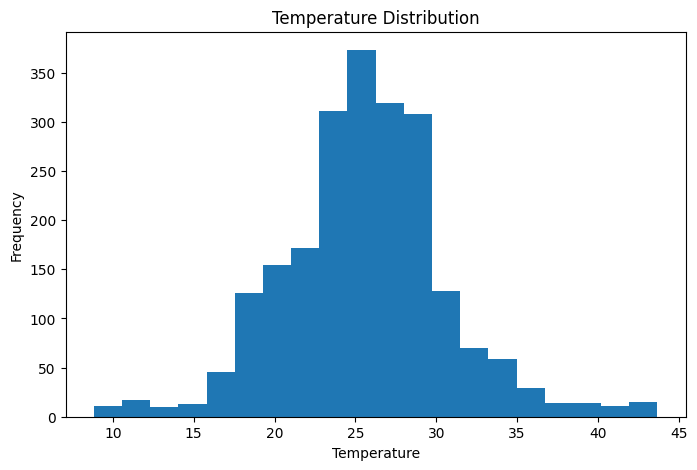

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['temperature'],bins=20)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

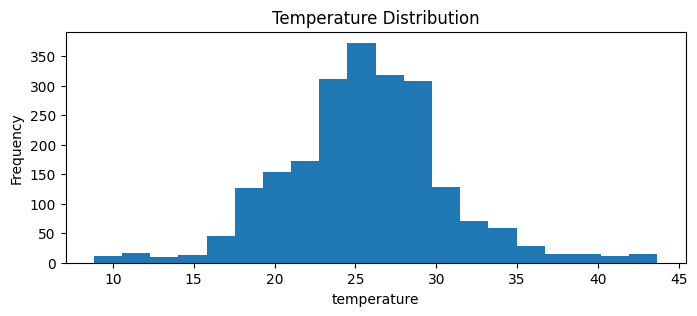

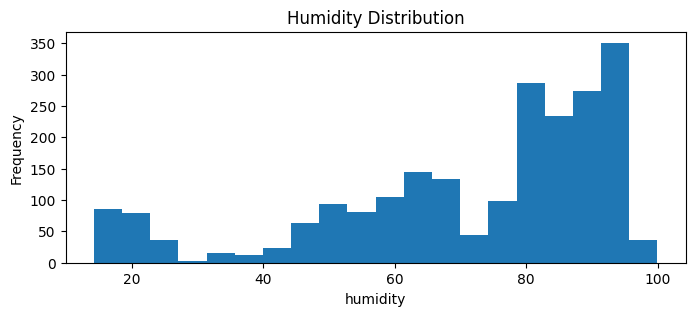

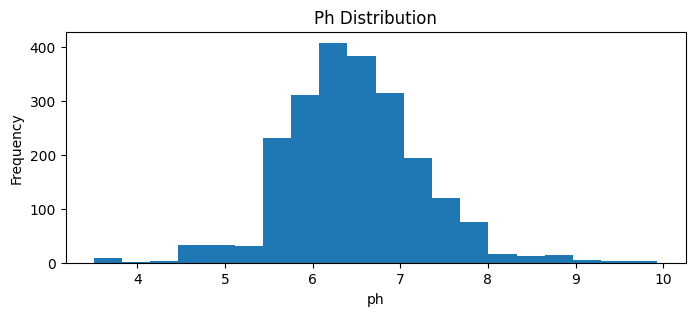

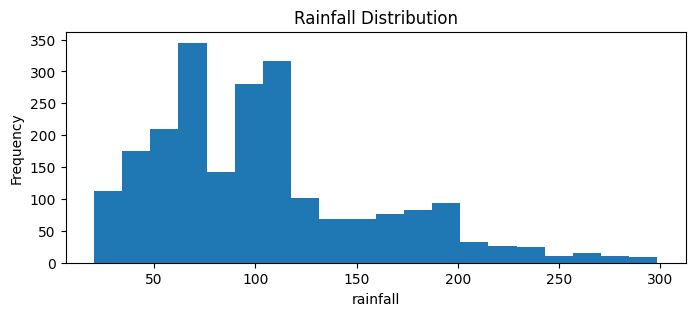

In [11]:
features=["temperature","humidity","ph","rainfall"]

for feature in features:
    plt.figure(figsize=(8,3))
    plt.hist(df[feature],bins=20)
    plt.title(f"{feature.capitalize()} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

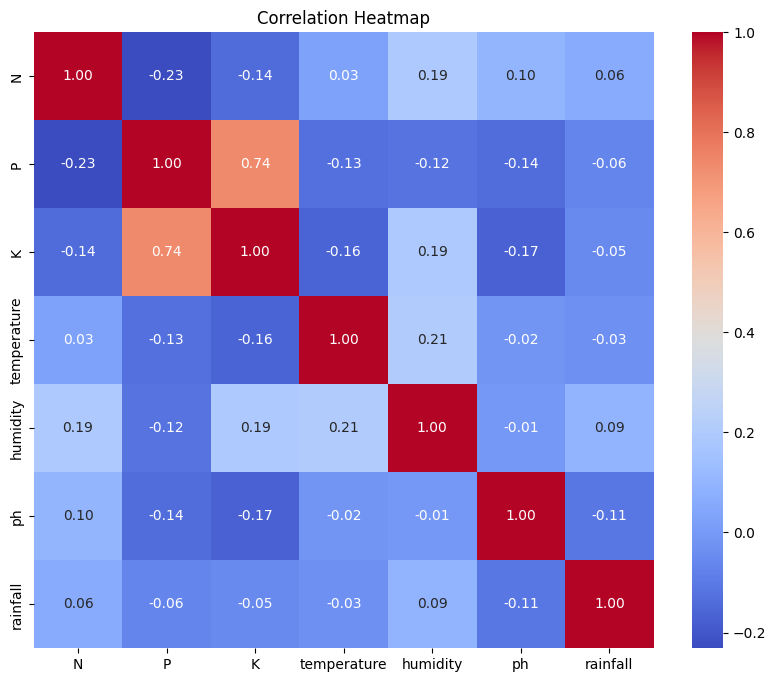

In [12]:
import seaborn as  sns

plt.figure(figsize=(10,8))

sns.heatmap(df.drop("label",axis=1).corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [13]:
x=df.drop("label",axis=1)
y=df["label"]

In [14]:
print(x.head())

    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340


In [15]:
print(y.head())

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [16]:
print(x.shape)
print(y.shape)

(2200, 7)
(2200,)


In [17]:
type(x)

pandas.core.frame.DataFrame

In [18]:
type(y)

pandas.core.series.Series

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.ensemble import RandomForestClassifier

In [21]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
y_pred=dt_model.predict(x_test)
y_pred[:10]

array(['muskmelon', 'watermelon', 'papaya', 'papaya', 'apple', 'mango',
       'apple', 'mothbeans', 'mungbean', 'lentil'], dtype=object)

In [23]:
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.9863636363636363

In [24]:
cm=confusion_matrix(y_pred,y_test)
cm

array([[23,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 27,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 22,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  2,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,

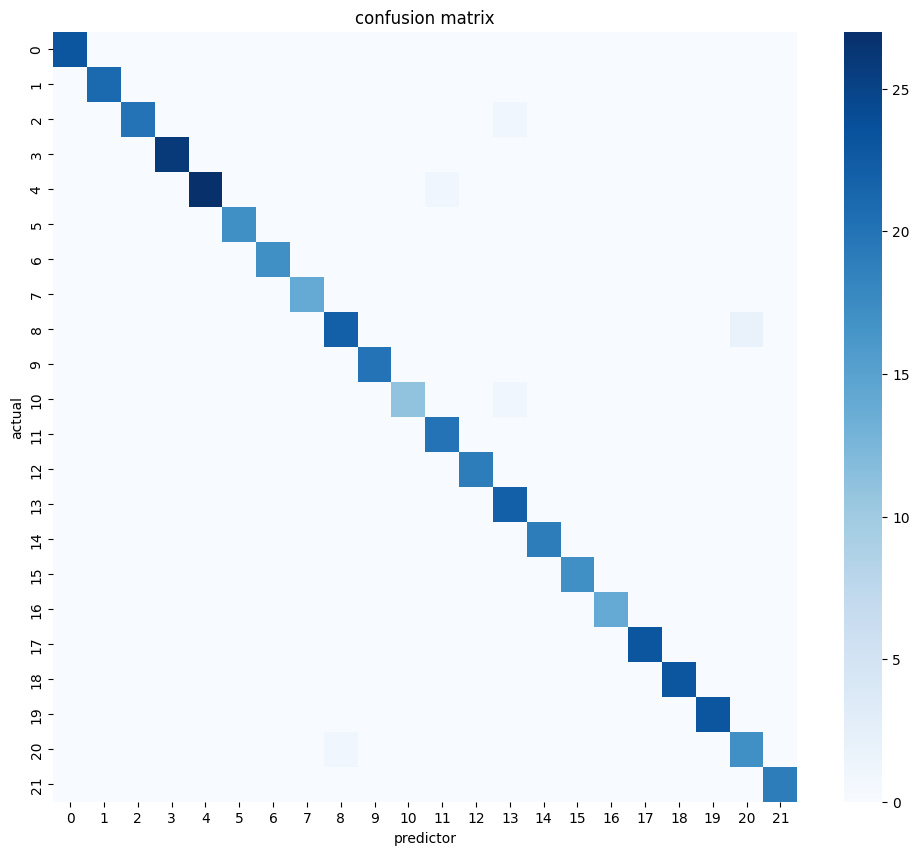

In [25]:
plt.figure(figsize=(12,10))

sns.heatmap(cm,cmap="Blues")
plt.title("confusion matrix")
plt.xlabel("predictor")
plt.ylabel("actual")
plt.show()

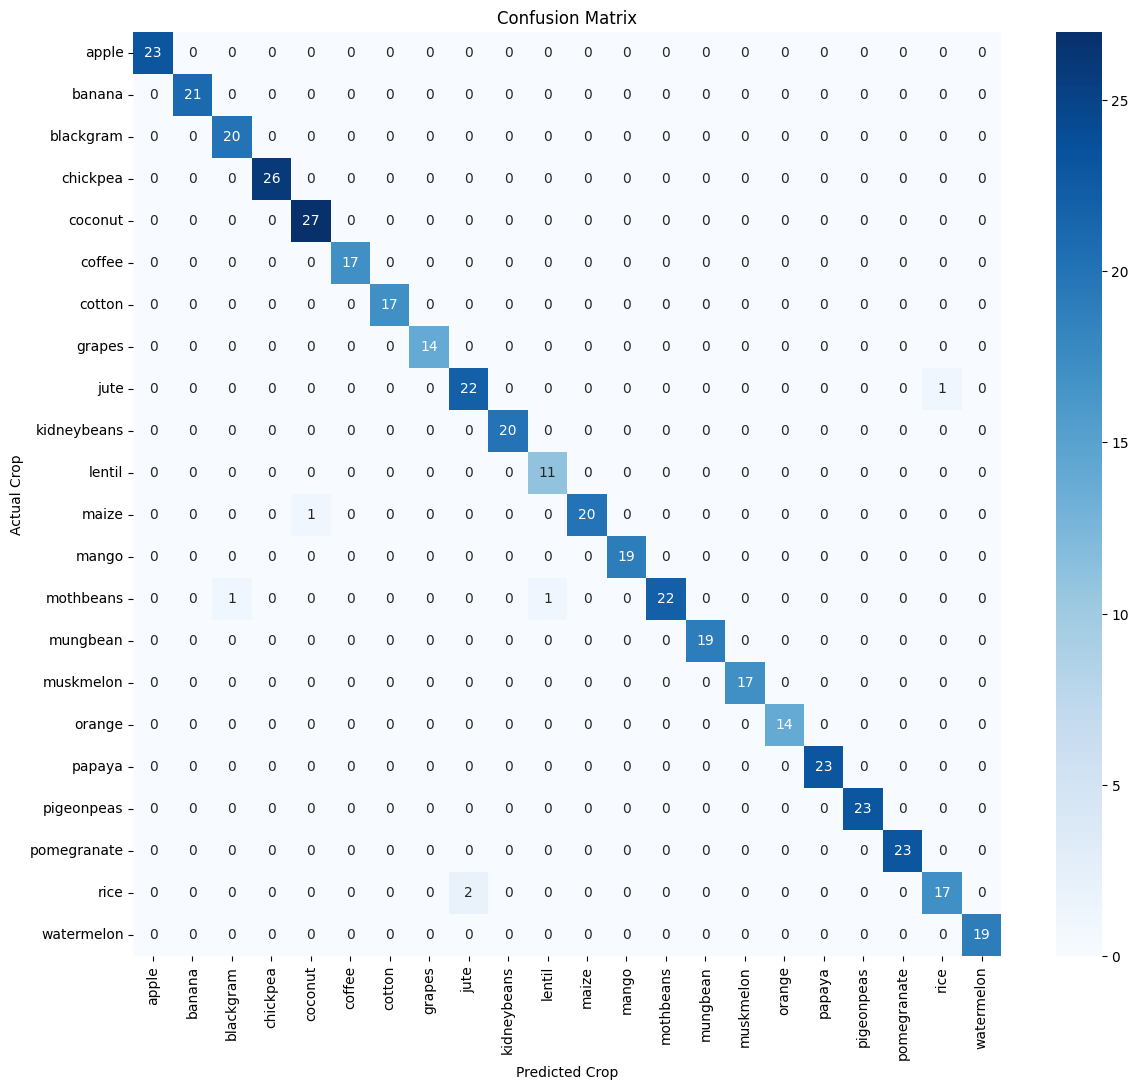

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

labels = sorted(df["label"].unique())

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [28]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred_rf=rf_model.predict(x_test)


In [30]:
rf_accuracy=accuracy_score(y_test,y_pred_rf)
rf_accuracy

0.9931818181818182

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
param_grid={
    "n_estimators":[50,100,200],
    "max_depth":[5,10,15]}

In [33]:
grid=GridSearchCV(rf_model,param_grid=param_grid,cv=5,scoring="accuracy")

In [34]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [35]:
grid.best_estimator_

RandomForestClassifier(max_depth=15, random_state=42)

In [36]:
grid.best_params_

{'max_depth': 15, 'n_estimators': 100}

In [37]:
grid.best_score_

np.float64(0.9954545454545455)

In [39]:
best_model=grid.best_estimator_

In [42]:
y_pred_best=best_model.predict(x_test)

In [44]:
best_accuracy=accuracy_score(y_test,y_pred_best)
best_accuracy

0.9931818181818182

In [45]:
feature_importance=best_model.feature_importances_
feature_importance

array([0.1086497 , 0.1422261 , 0.18184077, 0.07363516, 0.21302349,
       0.05272503, 0.22789976])

In [47]:
feature_names=x.columns
feature_names

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [48]:
importance_df=pd.DataFrame({"Feature":feature_names,"Importance":feature_importance})

In [50]:
importance_df=importance_df.sort_values(by="Importance",ascending=False)
importance_df

,Feature,Importance
6,rainfall,0.227900
4,humidity,0.213023
2,K,0.181841
1,P,0.142226
0,N,0.108650
3,temperature,0.073635
5,ph,0.052725


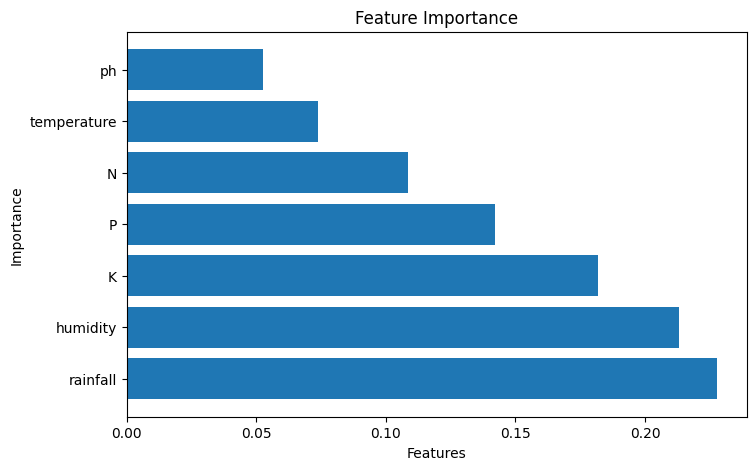

In [53]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"],importance_df["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [54]:
import joblib

joblib.dump(best_model,"../models/crop_recommendation_model.pkl")

['../models/crop_recommendation_model.pkl']